In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import IPython.display as ipd  # To play sound in the notebook
import os
from tqdm import tqdm
import datetime
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters
from keras.models import load_model
from pydub import AudioSegment, effects
from sklearn.utils import shuffle
import noisereduce as nr

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [12]:
RAVDESS = "Data/RAVDESS/audio_speech_actors_01-24/"
TESS = "Data/TESS/"
# EMOTIONS = {
#     1: 'neutral',
#     2: 'calm',
#     3: 'happy',
#     4: 'sad',
#     5: 'angry',
#     6: 'fear',
#     7: 'disgust',
#     8: 'surprise'
# }
EMOTIONS = {
    1: 'neutral',
    2: 'happy',
    3: 'sad',
    4: 'angry',
    5: 'fear',
    6: 'disgust',
    7: 'surprise'
}
SAMPLE_RATE=22050

In [13]:
RAVDESS_folder_names = os.listdir(RAVDESS)
RAVDESS_folder_names.sort()

file_emotions = []
file_gender = []
file_intensity = []
file_paths = []

# for i in RAVDESS_folder_names:
#     if os.path.isdir(RAVDESS + i):
#         file_names = os.listdir(RAVDESS + i)

#         for file in file_names:
#             parts = file.split('.')[0].split('-')
#             file_emotions.append(EMOTIONS[int(parts[2])])
#             # file_intensity.append(int(parts[3]))
#             if int(parts[6]) % 2 == 0:
#                 file_gender.append('female')
#             else:
#                 file_gender.append('male')
#             file_paths.append(RAVDESS + i + '/' + file)
for file in os.listdir(TESS):
    parts = file.split('.')[0].split('_')
    if parts[2] == 'ps':
        parts[2] = 'surprise'
    file_emotions.append(parts[2])
    if parts[0] == 'OAF':
        file_gender.append('male')
    else:
        file_gender.append('female')

    file_paths.append(TESS + file)
# print(file_emotions, file_gender, file_intensity, file_paths, sep="\n")

In [14]:
dataset = pd.DataFrame({
    'path': file_paths,
    'gender': file_gender,
    'emotion': file_emotions
})
# dataset['emotion'] = dataset['emotion'].map(EMOTIONS)
print('Shape=>', dataset.shape)
dataset.head(50)

Shape=> (2800, 3)


,path,gender,emotion
0,Data/TESS/YAF_wire_happy.wav,female,happy
1,Data/TESS/OAF_fat_disgust.wav,male,disgust
2,Data/TESS/OAF_bought_happy.wav,male,happy
3,Data/TESS/OAF_fit_neutral.wav,male,neutral
4,Data/TESS/YAF_dead_fear.wav,female,fear
5,Data/TESS/OAF_join_neutral.wav,male,neutral
6,Data/TESS/YAF_hall_happy.wav,female,happy
7,Data/TESS/YAF_hurl_neutral.wav,female,neutral
8,Data/TESS/OAF_king_angry.wav,male,angry
9,Data/TESS/OAF_rot_angry.wav,male,angry


In [15]:
dataset = shuffle(dataset)
# dataset = shuffle(dataset)

In [16]:
dataset.tail(10)

,path,gender,emotion
1028,Data/TESS/YAF_pearl_sad.wav,female,sad
1000,Data/TESS/OAF_chain_happy.wav,male,happy
1468,Data/TESS/YAF_room_disgust.wav,female,disgust
1626,Data/TESS/OAF_dodge_sad.wav,male,sad
1936,Data/TESS/OAF_void_ps.wav,male,surprise
2764,Data/TESS/YAF_soup_sad.wav,female,sad
1906,Data/TESS/OAF_dead_neutral.wav,male,neutral
953,Data/TESS/OAF_rag_happy.wav,male,happy
1272,Data/TESS/OAF_rat_happy.wav,male,happy
2433,Data/TESS/YAF_numb_neutral.wav,female,neutral


# Exploratry Data Analysis (EDA)

In [17]:
dataset['gender'].value_counts()

female    1400
male      1400
Name: gender, dtype: int64

In [18]:
dataset['emotion'].value_counts()

angry       400
disgust     400
fear        400
sad         400
happy       400
surprise    400
neutral     400
Name: emotion, dtype: int64

In [19]:
dataset['emotion'].value_counts(normalize=True) * 100

angry       14.285714
disgust     14.285714
fear        14.285714
sad         14.285714
happy       14.285714
surprise    14.285714
neutral     14.285714
Name: emotion, dtype: float64

In [20]:
male_sample = []
female_sample = []
for i in EMOTIONS.values():
    male_sample.append(dataset[dataset['emotion'] == i][
        dataset['gender'] == 'male']['path'].reset_index(drop=True)[0])
    female_sample.append(dataset[dataset['emotion'] == i][
        dataset['gender'] == 'female']['path'].reset_index(drop=True)[0])
print(male_sample)
print(female_sample)

['Data/TESS/OAF_sheep_neutral.wav', 'Data/TESS/OAF_beg_happy.wav', 'Data/TESS/OAF_hate_sad.wav', 'Data/TESS/OAF_doll_angry.wav', 'Data/TESS/OAF_read_fear.wav', 'Data/TESS/OAF_take_disgust.wav', 'Data/TESS/OAF_lease_ps.wav']
['Data/TESS/YAF_knock_neutral.wav', 'Data/TESS/YAF_long_happy.wav', 'Data/TESS/YAF_pole_sad.wav', 'Data/TESS/YAF_neat_angry.wav', 'Data/TESS/YAF_goose_fear.wav', 'Data/TESS/YAF_thumb_disgust.wav', 'Data/TESS/YAF_walk_ps.wav']


/var/folders/y6/4njssq5s2_764zsxh2lpvlvm0000gn/T/ipykernel_41665/1306359228.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  male_sample.append(dataset[dataset['emotion'] == i][
/var/folders/y6/4njssq5s2_764zsxh2lpvlvm0000gn/T/ipykernel_41665/1306359228.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  female_sample.append(dataset[dataset['emotion'] == i][


In [21]:
for emotion, path in zip(EMOTIONS.values(), male_sample):
    signal, sr = librosa.load(path, sr=SAMPLE_RATE)
    print(f"Emotion:{emotion}")
    # Play the Audio
    ipd.display(ipd.Audio(signal, rate=SAMPLE_RATE))

Emotion:neutral


Emotion:happy


Emotion:sad


Emotion:angry


Emotion:fear


Emotion:disgust


Emotion:surprise


In [22]:
for emotion, path in zip(EMOTIONS.values(), female_sample):
    signal, sr = librosa.load(path, sr=SAMPLE_RATE)
    print(f"Emotion:{emotion}")
    # Play the Audio
    ipd.display(ipd.Audio(signal, rate=SAMPLE_RATE))

Emotion:neutral


Emotion:happy


Emotion:sad


Emotion:angry


Emotion:fear


Emotion:disgust


Emotion:surprise


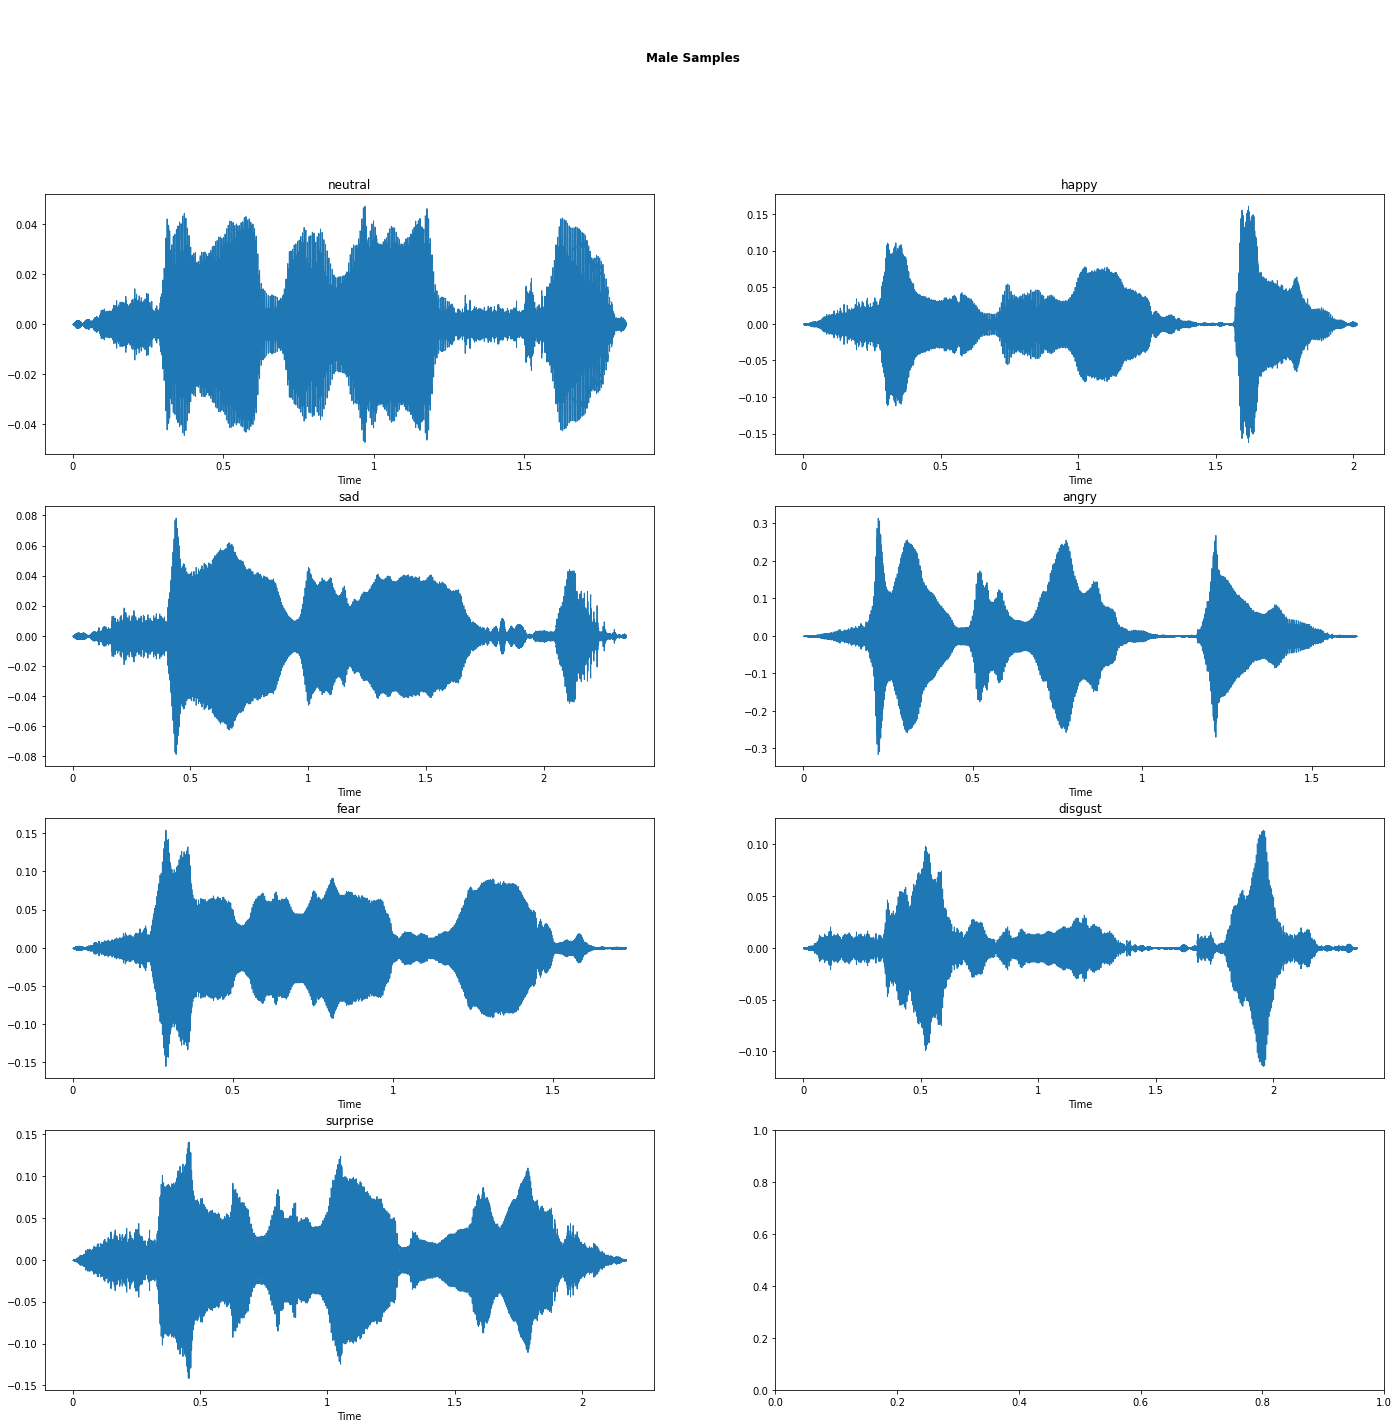

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(24, 22))
plt.suptitle("\n\n\nMale Samples", va='center', fontweight="bold")
for ax, emotion, path in zip(axes.flatten(), EMOTIONS.values(), male_sample):
    signal, sr = librosa.load(path, sr=SAMPLE_RATE)
    librosa.display.waveshow(signal, sr=SAMPLE_RATE, ax=ax)
    ax.set(title=emotion)

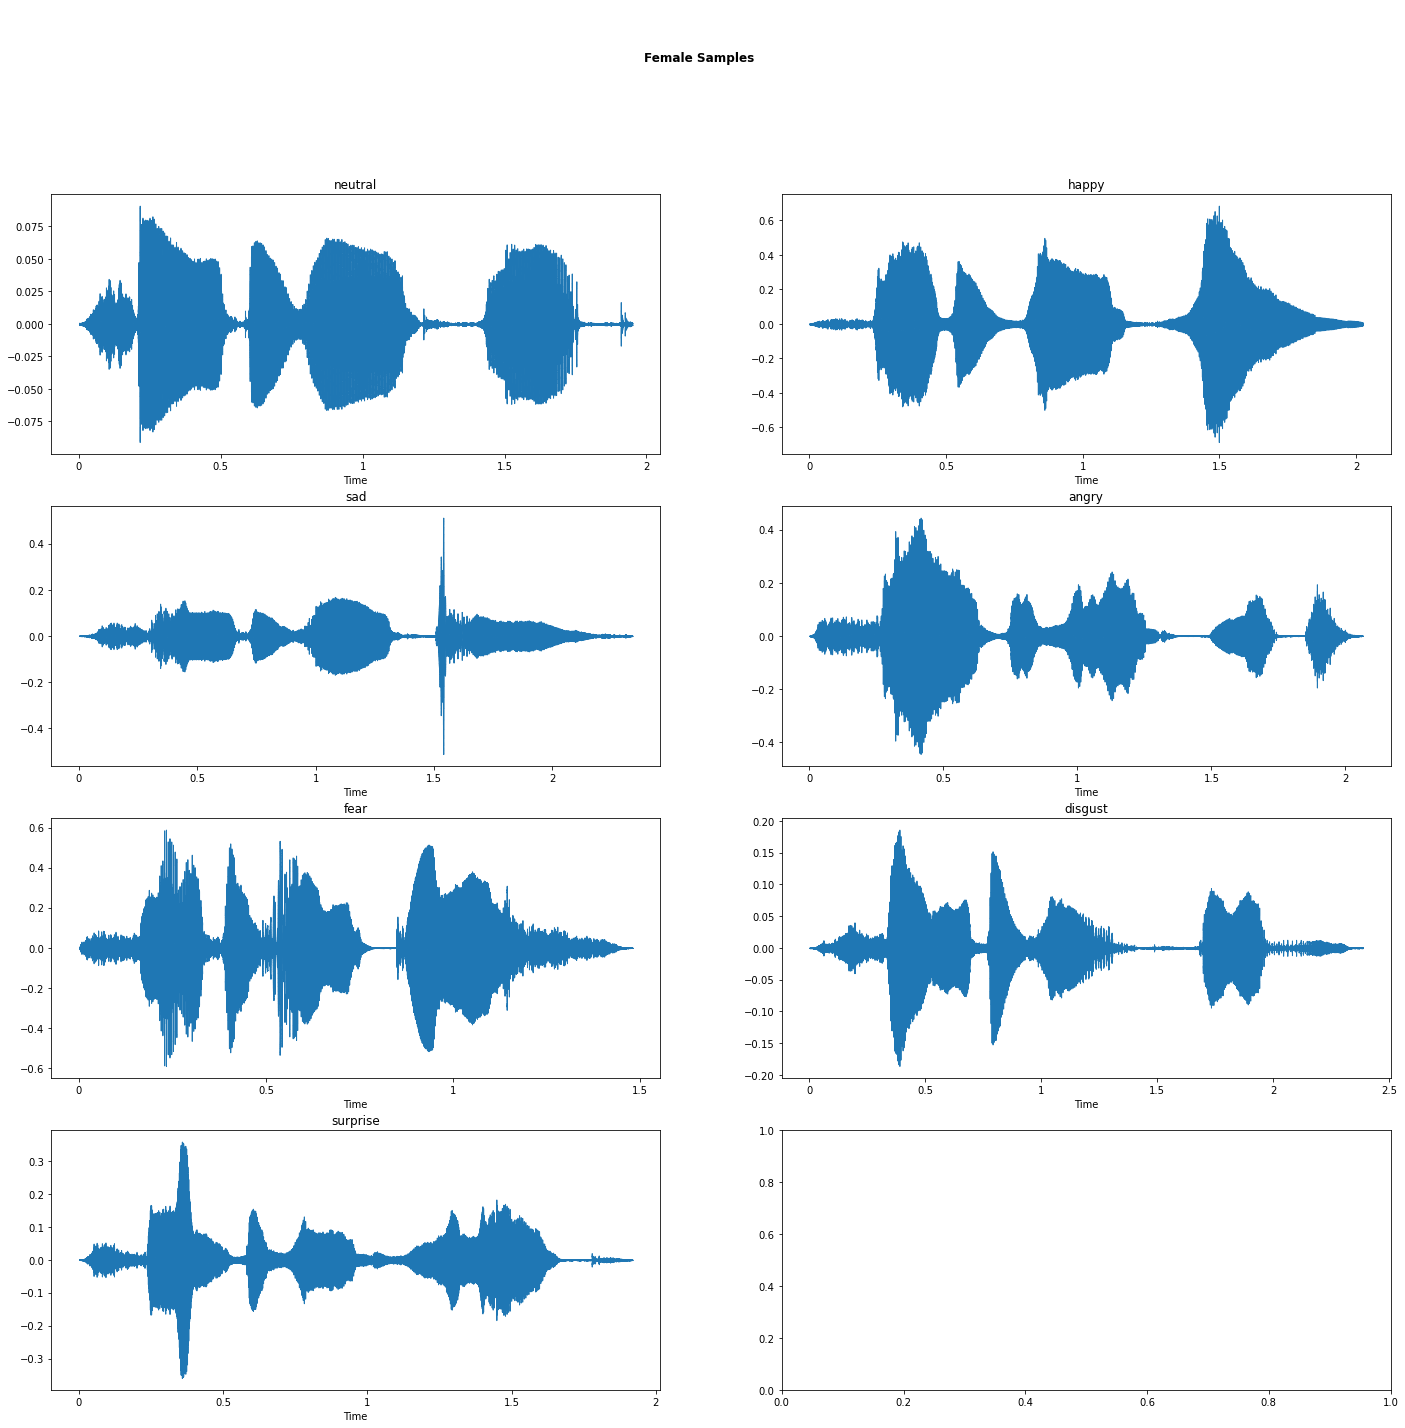

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(24, 22))
plt.suptitle("\n\n\nFemale Samples", va='center', fontweight="bold")
for ax, emotion, path in zip(axes.flatten(), EMOTIONS.values(), female_sample):
    signal, sr = librosa.load(path, sr=SAMPLE_RATE)
    librosa.display.waveshow(signal, sr=SAMPLE_RATE, ax=ax)
    ax.set(title=emotion)

# Preprocessing For Single File

Sample Rate :  24414


/var/folders/y6/4njssq5s2_764zsxh2lpvlvm0000gn/T/ipykernel_41665/3342237311.py:7: FutureWarning: Pass sr=24414 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  librosa.display.waveshow(ats, sr)


Text(0.5, 1.0, 'Initial audio')

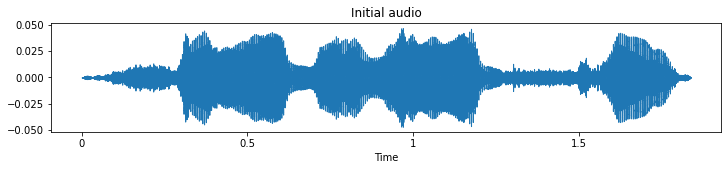

In [25]:
#Taking an audio file form male_sample to perform preprocessing to know the audio data more
path = male_sample[0]
rawsound = AudioSegment.from_file(path)
ats, sr = librosa.load(path, sr=None)
print("Sample Rate : ", sr)
plt.figure(figsize=(12, 2))
librosa.display.waveshow(ats, sr)
plt.title('Initial audio')

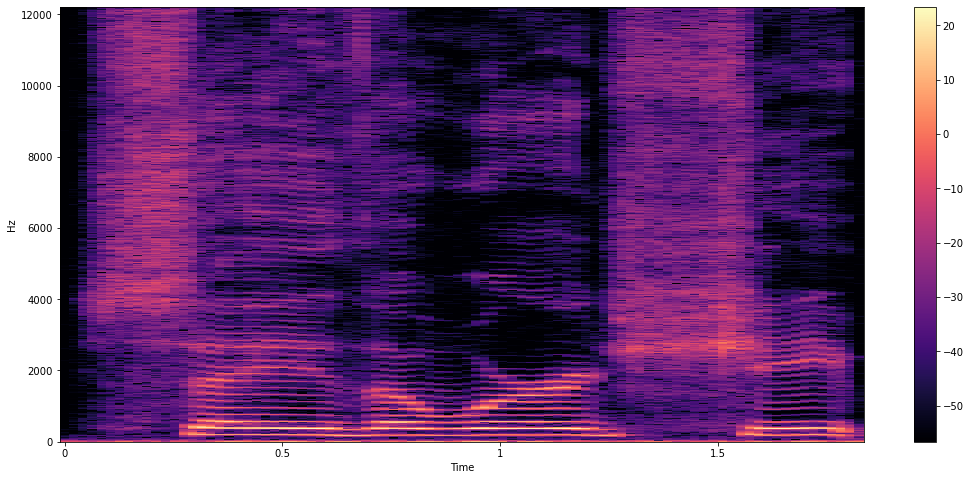

In [26]:
X = librosa.stft(ats)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize=(18, 8))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()

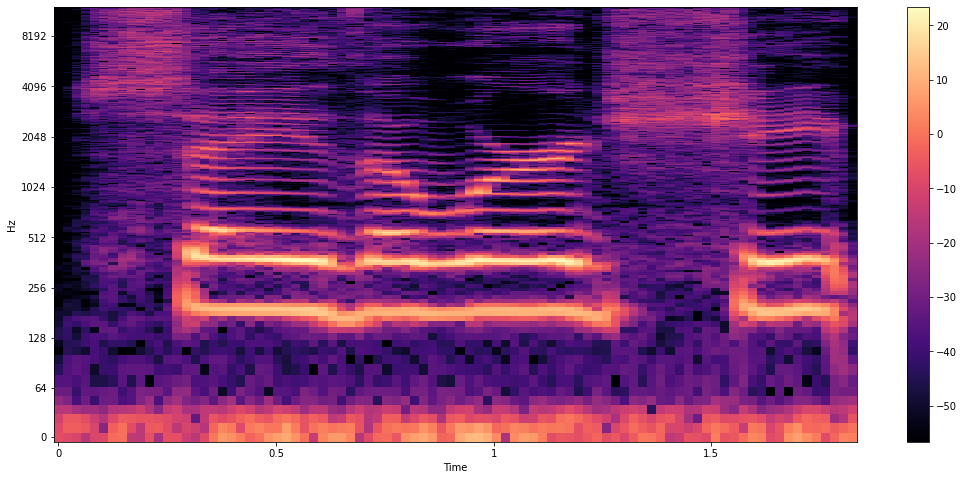

In [27]:
plt.figure(figsize=(18, 8))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()

/var/folders/y6/4njssq5s2_764zsxh2lpvlvm0000gn/T/ipykernel_41665/3066147956.py:8: FutureWarning: Pass sr=24414 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  librosa.display.waveshow(normal_audio, sr)


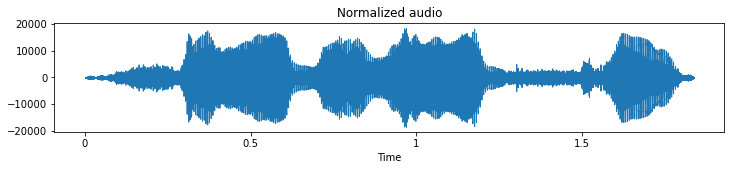

In [28]:
# Normalizing the audio to give audio boost to quiter part by giving +5.0 dBFS (decibels relative to full scale)
# and transforing normalized audio to Numpy array
normalizedsound = effects.normalize(rawsound, headroom=5.0)
normal_audio = np.array(normalizedsound.get_array_of_samples(),
                        dtype='float32')

plt.figure(figsize=(12, 2))
librosa.display.waveshow(normal_audio, sr)
plt.title('Normalized audio')

normalizedsound

/var/folders/y6/4njssq5s2_764zsxh2lpvlvm0000gn/T/ipykernel_41665/3826362084.py:5: FutureWarning: Pass sr=24414 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  librosa.display.waveshow(trimmed_audio, sr)


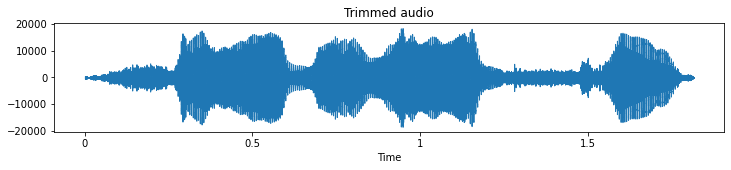

In [29]:
# Trimming the audio to remover silence before and after speech
trimmed_audio, index = librosa.effects.trim(normal_audio, top_db=30)

plt.figure(figsize=(12, 2))
librosa.display.waveshow(trimmed_audio, sr)
plt.title('Trimmed audio')

ipd.display(ipd.Audio(data=trimmed_audio, rate=sr))

/var/folders/y6/4njssq5s2_764zsxh2lpvlvm0000gn/T/ipykernel_41665/2925237830.py:8: FutureWarning: Pass sr=24414 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  librosa.display.waveshow(padded_audio, sr)


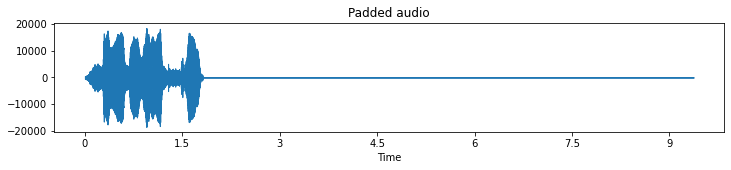

In [30]:
# Padding some values to right side to make all data length equal
# so we have maximum lenght audio file with 173056

padded_audio = np.pad(trimmed_audio, (0, 228864 - len(trimmed_audio)),
                      'constant')

plt.figure(figsize=(12, 2))
librosa.display.waveshow(padded_audio, sr)
plt.title('Padded audio')

ipd.display(ipd.Audio(data=padded_audio, rate=sr))

/var/folders/y6/4njssq5s2_764zsxh2lpvlvm0000gn/T/ipykernel_41665/610437427.py:5: FutureWarning: Pass sr=24414 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  librosa.display.waveshow(final_audio, sr)


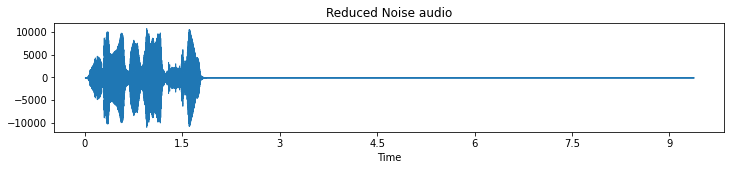

In [31]:
# Eliminating noise from audio by performing Noise Reduction
final_audio = nr.reduce_noise(padded_audio, sr)

plt.figure(figsize=(12, 2))
librosa.display.waveshow(final_audio, sr)
plt.title('Reduced Noise audio')

ipd.display(ipd.Audio(data=final_audio, rate=sr))

# Feature Selection For Single File

Energy shape: (1, 448)
ZCR shape: (1, 448)
MFCCs shape: (20, 448)
Spectral Centroid shape: (1, 448)
chroma feature shape: (12, 448)


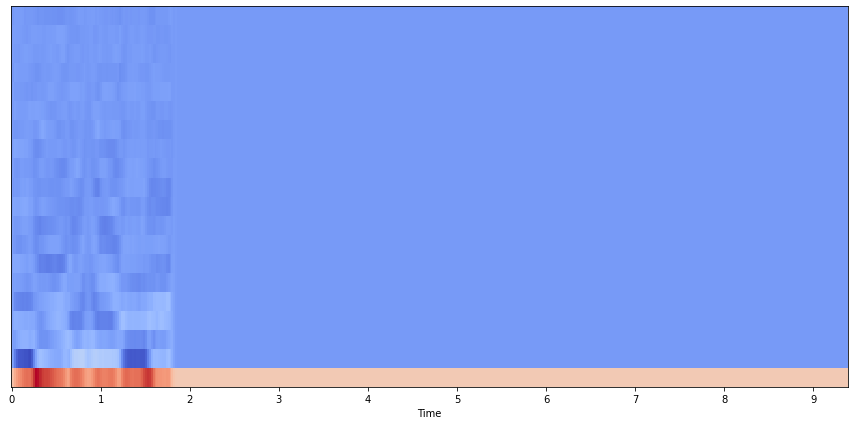

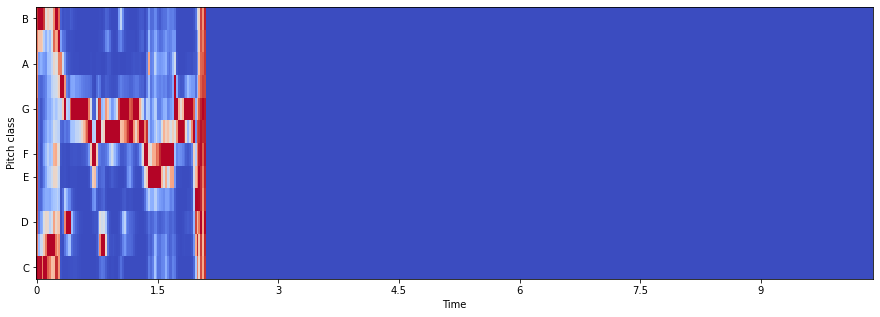

In [32]:
f1 = librosa.feature.rms(y=final_audio)  # Energy - Root Mean Square (RMS)
print('Energy shape:', f1.shape)

f2 = librosa.feature.zero_crossing_rate(
    y=final_audio)  # Zero Crossed Rate (ZCR)
print('ZCR shape:', f2.shape)

f3 = librosa.feature.mfcc(y=final_audio, sr=sr)  # MFCCs
print('MFCCs shape:', f3.shape)
plt.figure(figsize=(15, 7))
librosa.display.specshow(f3, sr=sr, x_axis='time')

f4 = librosa.feature.spectral_centroid(y=final_audio,
                                       sr=sr)  # pectral centroid
print('Spectral Centroid shape:', f4.shape)

f5 = librosa.feature.chroma_stft(y=final_audio, sr=sr)  # chroma feature
print('chroma feature shape:', f5.shape)
plt.figure(figsize=(15, 5))
librosa.display.specshow(f5, x_axis='time', y_axis='chroma', cmap='coolwarm')

In [52]:
import time

tic = time.perf_counter()
# scaler = StandardScaler()

# Initialize data lists
rms = []
# zcr = []
mfcc = []
# sc = []
cf = []
mel = []
emotions = []
max_length = 65303
frame_length = 2048
hop_length = 512
sr = 22050
for path, emotion in dataset[['path', 'emotion']].to_numpy():

    # Fetch the sample rate.
    rawsound, _ = librosa.load(
        path=path)
    # print(sr)
    # sr (the sample rate) is used for librosa's MFCCs. '_' is irrelevant.
    # Load the audio file.
    # rawsound = AudioSegment.from_file(path)
    # Normalize the audio to +5.0 dBFS.
    # normalizedsound = effects.normalize(rawsound, headroom=5.0)
    normalizedsound = librosa.util.normalize(rawsound)
    # Transform the normalized audio to np.array of samples.
    # normal_audio = np.array(normalizedsound.get_array_of_samples(),
    #                         dtype='float32')
    # Trim silence from the beginning and the end.
    trimmed_audio, index = librosa.effects.trim(y=normalizedsound, top_db=30)
    # print(len(trimmed_audio))
    # Pad for duration equalization.
    if len(trimmed_audio) > max_length:
        continue
    final_audio = np.pad(trimmed_audio, (0, max_length - len(trimmed_audio)),
                          'constant')
    # Noise reduction.
    # final_audio = nr.reduce_noise(y=padded_audio, sr=sr)  #updated 03/03/22

    # Features extraction
    f1 = librosa.feature.rms(
        y=final_audio, frame_length=frame_length,
        hop_length=hop_length).T  # Energy - Root Mean Square
    # f2 = librosa.feature.zero_crossing_rate(y=final_audio,
    #                                         frame_length=frame_length,
    #                                         hop_length=hop_length,
    #                                         center=True).T  # ZCR
    f3 = librosa.feature.mfcc(y=final_audio,
                              sr=sr,
                              n_mfcc=80,
                              hop_length=hop_length).T  # MFCC

    # f4 = librosa.feature.spectral_centroid(
    #     y=final_audio, sr=sr, hop_length=hop_length).T  # pectral centroid

    f5 = librosa.feature.chroma_stft(y=final_audio, sr=sr).T  # chroma feature
    f6 = librosa.feature.melspectrogram(y=final_audio,
                                        n_fft=frame_length,
                                        hop_length=hop_length).T

    # Filling the data lists

    rms.append(f1)
    # zcr.append(scaler.fit_transform(f2))
    mfcc.append(f3)
    # sc.append(f4)
    cf.append(f5)
    mel.append(f6)
    emotions.append(tuple(EMOTIONS.values()).index(emotion))
    
f_rms = np.asarray(rms)
# f_zcr = np.asarray(zcr)
f_mfccs = np.asarray(mfcc)
# f_sc = np.asarray(sc)
f_cf = np.asarray(cf)
f_mel = np.asarray(mel)
# Concatenating all features to 'X' variable.
X = np.concatenate(( f_rms,f_mfccs,f_sc,f_cf,f_mel), axis=2)
# Preparing 'Y' as a 2D shaped variable.
Y = np.asarray(emotions)
Y = np.expand_dims(Y, axis=1)
enc = OneHotEncoder()
Y = enc.fit_transform(Y)
Y = Y.toarray()
toc = time.perf_counter()
print(f"Running time: {(toc - tic)/60:0.4f} minutes")

Running time: 2.9357 minutes


In [54]:
# f_rms = np.asarray(rms).astype('float32')
# f_rms = np.swapaxes(f_rms, 1, 2)
# f_zcr = np.asarray(zcr).astype('float32')
# f_zcr = np.swapaxes(f_zcr, 1, 2)
# f_mfccs = np.asarray(mfcc).astype('float32')
# f_mfccs = np.swapaxes(f_mfccs, 1, 2)
# f_sc = np.asarray(sc).astype('float32')
# f_sc = np.swapaxes(f_sc, 1, 2)
# f_cf = np.asarray(cf).astype('float32')
# f_cf = np.swapaxes(f_cf, 1, 2)

# print('ZCR shape:', f_zcr.shape)
print('RMS shape:', f_rms.shape)
print('MFCCs shape:', f_mfccs.shape)
print('SC shape:', f_sc.shape)
print('CF shape:', f_cf.shape)
print('mel shape:', f_mel.shape)

print('X shape:', X.shape)
print('Y shape:', Y.shape)

RMS shape: (2800, 128, 1)
MFCCs shape: (2800, 128, 80)
SC shape: (2800, 128, 1)
CF shape: (2800, 128, 12)
mel shape: (2800, 128, 128)
X shape: (2800, 128, 222)
Y shape: (2800, 7)


In [55]:
np.min(X), np.max(X)

(-637.6939086914062, 8569.981518921168)

In [ ]:
# # Concatenating all features to 'X' variable.
# X = np.concatenate((f_zcr, f_rms, f_mfccs, f_sc, f_cf), axis=2)
# # Preparing 'Y' as a 2D shaped variable.
# Y = np.asarray(emotions).astype('int8')
# Y = np.expand_dims(Y, axis=1)

In [ ]:
# # Saving Numpy arrays as Features and Labels
np.save('Features.npy', X)
np.save('Labels.npy', Y)

In [ ]:
# X = np.load('Features.npy')
# Y = np.load('Labels.npy')

# Model Training

In [38]:
from keras.models import Sequential
import tensorflow as tf
from keras import layers
from keras import optimizers
from keras import callbacks
from keras.layers import Dropout
from keras.layers import LSTM, Dense

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [73]:
# Initializing the model

model = Sequential()
model.add(layers.LSTM(192, return_sequences=True, input_shape=(X.shape[1:3])))
# model.add(layers.LSTM(192, return_sequences=True))
# model.add(layers.LSTM(256,return_sequences=True))
# model.add(layers.LSTM(192, return_sequences=True))
# model.add(layers.LSTM(32))

# model.add(layers.LSTM(128, return_sequences=True))
model.add(layers.LSTM(192))


# model.add(layers.Dropout(0.2))
# model.add(layers.Dense(390, activation='relu'))
# model.add(layers.Dropout(0.2))
# model.add(layers.Dense(128, activation='relu'))
# model.add(layers.Dropout(0.2))
# model.add(layers.Dense(28, activation='relu'))
# model.add(layers.Dropout(0.2))
# model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))

model.add(layers.Dense(7, activation='softmax'))
print(model.summary())

batch_size = 256

# Callbacks functions
checkpoint_path = 'Models/best_weights.hdf5'

#-> Save the best weights
mcp_save = callbacks.ModelCheckpoint(checkpoint_path,
                                     save_best_only=True,
                                     monitor='val_categorical_accuracy',
                                     mode='max')
#-> Reduce learning rate after 100 epoches without improvement.
rlrop = callbacks.ReduceLROnPlateau(monitor='val_categorical_accuracy',
                                    factor=0.01,
                                    patience=20)

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_25 (LSTM)              (None, 128, 192)          318720    
                                                                 
 lstm_26 (LSTM)              (None, 192)               295680    
                                                                 
 dense_23 (Dense)            (None, 16)                3088      
                                                                 
 dense_24 (Dense)            (None, 7)                 119       
                                                                 
Total params: 617,607
Trainable params: 617,607
Non-trainable params: 0
_________________________________________________________________
None


In [74]:
# optimizer = keras.optimizers.Adam(learning_rate=0.001)
# optimizer = keras.optimizers.RMSprop(learning_rate=0.001)

model.compile(loss='categorical_crossentropy',
              optimizer="adam",
              metrics=['categorical_accuracy'])
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
                                                      histogram_freq=1)

history = model.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    callbacks=[mcp_save, rlrop, tensorboard_callback],
                    shuffle=True)
# Define the best weights to the model.
model.load_weights(checkpoint_path)

Epoch 1/100


2022-07-20 16:13:21.743903: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:13:21.950110: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:13:22.110266: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:13:22.320117: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:13:22.640204: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


9/9 [==============================] - ETA: 0s - loss: 1.8779 - categorical_accuracy: 0.2071

2022-07-20 16:13:24.843657: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:13:24.929911: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:13:25.095296: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


9/9 [==============================] - 5s 334ms/step - loss: 1.8779 - categorical_accuracy: 0.2071 - val_loss: 1.7203 - val_categorical_accuracy: 0.3196 - lr: 0.0010
Epoch 2/100
9/9 [==============================] - 1s 143ms/step - loss: 1.5926 - categorical_accuracy: 0.3201 - val_loss: 1.3716 - val_categorical_accuracy: 0.3804 - lr: 0.0010
Epoch 3/100
9/9 [==============================] - 1s 129ms/step - loss: 1.2726 - categorical_accuracy: 0.4781 - val_loss: 1.0642 - val_categorical_accuracy: 0.5143 - lr: 0.0010
Epoch 4/100
9/9 [==============================] - 1s 129ms/step - loss: 0.9259 - categorical_accuracy: 0.6839 - val_loss: 0.6915 - val_categorical_accuracy: 0.7464 - lr: 0.0010
Epoch 5/100
9/9 [==============================] - 1s 130ms/step - loss: 0.5967 - categorical_accuracy: 0.8058 - val_loss: 0.4979 - val_categorical_accuracy: 0.8089 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 1s 135ms/step - loss: 0.4498 - categorical_accuracy: 0.8330 - val_loss:

In [75]:
model = load_model('Models/best_weights.hdf5')
model.compile(loss='categorical_crossentropy',
              optimizer="adam",
              metrics=['categorical_accuracy'])

In [76]:
loss, acc = model.evaluate(X_test, y_test, verbose=2)

2022-07-20 16:15:23.393134: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:15:23.473263: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 16:15:23.625188: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


18/18 - 1s - loss: 0.0518 - categorical_accuracy: 0.9911 - 1s/epoch - 82ms/step


In [ ]:
loss, acc = model.evaluate(X, Y, verbose=2)

In [ ]:
tf.keras.utils.plot_model(model,
                          to_file='model.png',
                          show_shapes=True,
                          show_layer_names=True)